In [1]:
# Clone repo if not already cloned
!git clone https://github.com/venk-meg/STRIKE.git
%cd STRIKE

import os
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Load all gesture CSV files
base_dir = "data_ml"
gestures = [g for g in os.listdir(base_dir) if not g.startswith(".")]

all_samples = []
for gesture in gestures:
    gesture_dir = os.path.join(base_dir, gesture)
    files = [f for f in os.listdir(gesture_dir) if f.endswith(".csv") and f != ".gitkeep"]
    for filename in files:
        df = pd.read_csv(os.path.join(gesture_dir, filename))
        df['gesture'] = gesture
        df['take_id'] = f"{gesture}_{filename.split('.')[0]}"
        all_samples.append(df)

full_df = pd.concat(all_samples, ignore_index=True)

# Cleanup: remove non-numeric or duplicate header rows
meta_cols = ['timestamp', 'gesture', 'take_id']
sensor_cols = [col for col in full_df.columns if col not in meta_cols]

for col in sensor_cols:
    full_df = full_df[full_df[col] != col]

full_df[sensor_cols] = full_df[sensor_cols].apply(pd.to_numeric, errors='coerce')
full_df[sensor_cols] = full_df[sensor_cols].ffill().bfill().fillna(0)

# Recompute sensor columns (in case of dtype coercion)
sensor_cols = full_df.select_dtypes(include='number').columns.tolist()

# Feature extraction: diff + stats per take
feature_rows = []
for take_id, group in full_df.groupby("take_id"):
    gesture = group['gesture'].iloc[0]
    diff_df = group[sensor_cols].diff().dropna()
    stats = diff_df.agg(['mean', 'std', 'min', 'max'])

    try:
        stats.columns = [f"{col}_{stat}" for col, stat in stats.columns]
    except ValueError:
        stats.columns = [f"{col}_{stats.index[0]}" for col in stats.columns]

    feature_row = stats.values.flatten()
    feature_rows.append({
        'take_id': take_id,
        'gesture': gesture,
        'features': feature_row
    })

# Prepare training data
X = np.array([row['features'] for row in feature_rows])
y = np.array([row['gesture'] for row in feature_rows])

# Encode labels to integers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-hot encode labels
y_cat = to_categorical(y_encoded, num_classes=num_classes)

# Normalize input features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat, test_size=0.2, stratify=y_cat, random_state=42
)

# Build model
model = Sequential([
    Dense(32, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
model.fit(X_train, y_train, epochs=40, batch_size=8, validation_data=(X_test, y_test))

# Convert to float32 TFLite model
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save model
with open("gesture_model.tflite", "wb") as f:
    f.write(tflite_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

with open("gesture_model_quant.tflite", "wb") as f:
    f.write(tflite_quant_model)

# convert to .h dile
with open("gesture_model_quant.tflite", "rb") as f:
    byte_data = f.read()

with open("gesture_model_quant.h", "w") as h:
    h.write("const unsigned char gesture_model_quant_tflite[] = {\n")
    for i, b in enumerate(byte_data):
        h.write(f"0x{b:02x}, ")
        if (i + 1) % 12 == 0:
            h.write("\n")
    h.write("\n};\n")
    h.write(f"const unsigned int gesture_model_quant_tflite_len = {len(byte_data)};\n")



Cloning into 'STRIKE'...
remote: Enumerating objects: 658, done.
remote: Counting objects: 100% (381/381), done.
remote: Compressing objects: 100% (381/381), done.
remote: Total 658 (delta 148), reused 0 (delta 0), pack-reused 277 (from 2)
Receiving objects: 100% (658/658), 9.92 MiB | 6.68 MiB/s, done.
Resolving deltas: 100% (280/280), done.
/content/STRIKE


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1840 - loss: 2.1454 - val_accuracy: 0.2400 - val_loss: 1.9821
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2312 - loss: 1.9071 - val_accuracy: 0.3200 - val_loss: 1.8089
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3551 - loss: 1.6635 - val_accuracy: 0.3600 - val_loss: 1.6695
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4528 - loss: 1.5712 - val_accuracy: 0.4600 - val_loss: 1.5386
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5406 - loss: 1.4550 - val_accuracy: 0.5400 - val_loss: 1.4050
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6567 - loss: 1.1929 - val_accuracy: 0.6600 - val_loss: 1.2747
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6966 - loss: 1.1561 - val_accuracy: 0.7400 - val_loss: 1.1477
Epoch 8/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7466 - loss: 0.9839 - val_accuracy: 0.8200 - val_loss

## Model Evaluation

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

📄 Classification Report:
                 precision    recall  f1-score   support

deleterecording       1.00      1.00      1.00         6
         listen       1.00      1.00      1.00         6
       makefist       1.00      0.83      0.91         6
  nextrecording       0.86      1.00      0.92         6
    releasefist       1.00      1.00      1.00         6
           rest       0.86      0.75      0.80         8
      selectend       0.86      1.00      0.92         6
          slice       1.00      1.00      1.00         6

       accuracy                           0.94        50
      macro avg       0.95      0.95      0.94        50
   weighted avg       0.94      0.94      0.94        50



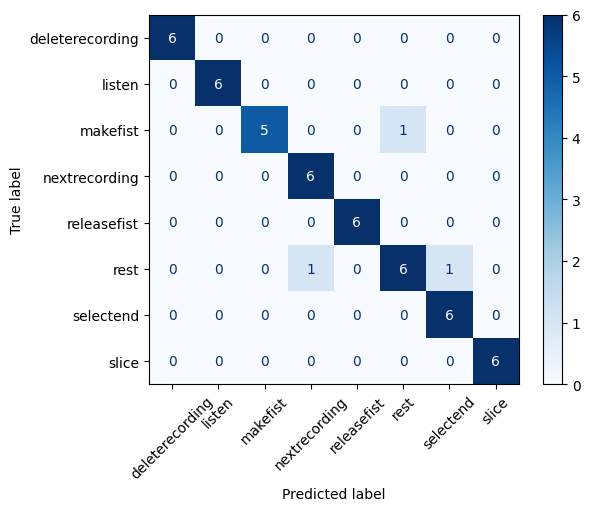

In [2]:
# Evaluation
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict labels (probabilities → class indices)
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Decode integer labels to original gestures
y_pred_labels = le.inverse_transform(y_pred_classes)
y_true_labels = le.inverse_transform(y_true_classes)

# Print detailed report
print("\n📄 Classification Report:")
print(classification_report(y_true_labels, y_pred_labels))

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true_labels, y_pred_labels, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)



## class labels for deployment

In [3]:
# Save your label map
import json
with open("gesture_labels.json", "w") as f:
    json.dump(list(le.classes_), f)

## downloading files to push on github

In [4]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files
files.download("gesture_model_quant.tflite")
files.download("gesture_labels.json")
files.download("gesture_model.tflite")
files.download("gesture_model_quant.h")

Mounted at /content/drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>